# pybalmorel for Post-Processing
This notebook provide examples on how to use pybalmorel for pre-processing, post-processing and for executing Balmorel scenarios. Check the following pages:
- [Home](../README.md)
- [Pre-Processing](PreProcessing.ipynb)
- [Execution](Execution.ipynb)

In [1]:
import os
import pandas as pd
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Adjust the sys.path to include the project root directory
project_root = os.path.abspath(os.path.join(os.path.dirname("__file__"), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
from src.pybalmorel import MainResults
from src.pybalmorel.plotting import plot_functions as pf

gams_system_directory = "/Library/Frameworks/GAMS.framework/Versions/54/Resources/"

In [2]:
# ### 1.1.2 Loading several scenarios
# res = MainResults(files=['MainResults_NZwoCCS.gdx',
#                          'MainResults_NZwoCCS_v2.gdx',
#                         'MainResults_NZwCCS2.gdx',
#                         'MainResults_NZwCCS_v3.gdx',
#                         'MainResults_CO2TaxwCCS_S26.gdx',
#                         'MainResults_NNwCCS.gdx',
#                         'MainResults_NNwCCS_v3.gdx',
#                         'MainResults_NZwCCSBio_s26.gdx'],
#                     paths=['Balmorel/02Project_NZwithoutCCS/Model',
#                            'Balmorel/02Project_NZwithoutCCS_S26/Model',
#                             'Balmorel/03Project_NZwCCS/Model',
#                             'Balmorel/03Project_NZwCCS_S26/Model',
#                             'Balmorel/04Project_CO2TaxwCCS_S26/Model',
#                             'Balmorel/05Project_NNwCCS/Model',
#                             'Balmorel/05Project_NNwCCS_S26/Model',
#                             'Balmorel/06Project_NZwCCSBio_S26/Model'],
#                     scenario_names=['Net-Zero w/o CCS', 
#                                     'Net-Zero w/o CCS s26', 
#                                     'Net-Zero w CCS', 
#                                     'Net-Zero w CCS s26', 
#                                     'CO2 Tax w CCS s26', 
#                                     'Net-Negative w CCS', 
#                                     'Net-Negative w CCS s26',
#                                     'Net-Zero w CCS and bio emissions s26'],
#                     system_directory=gams_system_directory)


In [2]:
### 1.1.2 Loading several scenarios
res = MainResults(files=['MainResults_NZwoCCS_v2.gdx',
                        'MainResults_NZwCCS_v3.gdx',
                        'MainResults_CO2TaxwCCS_S26.gdx',
                        'MainResults_CO2TaxwCCS_S26_tax068.gdx',
                        'MainResults_CO2TaxwCCS_S26_tax136.gdx',
                        'MainResults_NNwCCS_v3.gdx',
                        'MainResults_NZwCCSBio_s26.gdx'],
                    paths=['Balmorel/02Project_NZwithoutCCS_S26/Model',
                            'Balmorel/03Project_NZwCCS_S26/Model',
                            'Balmorel/04Project_CO2TaxwCCS_S26/Model',
                            'Balmorel/04Project_CO2TaxwCCS_S26_tax068/Model',
                            'Balmorel/04Project_CO2TaxwCCS_S26_tax136/Model',
                            'Balmorel/05Project_NNwCCS_S26/Model',
                            'Balmorel/06Project_NZwCCSBio_S26/Model'],
                    scenario_names=['Net-Zero w/o CCS',
                                    'Net-Zero w CCS', 
                                    'CO2 Tax w CCS', 
                                    '0.68 CO2 Tax w CCS',
                                    '1.36 CO2 Tax w CCS',
                                    'Net-Negative w CCS',
                                    'Net-Zero w CCS and bio emissions'],
                    system_directory=gams_system_directory)

Loading Balmorel/02Project_NZwithoutCCS_S26/Model/MainResults_NZwoCCS_v2.gdx
Loading Balmorel/03Project_NZwCCS_S26/Model/MainResults_NZwCCS_v3.gdx
Loading Balmorel/04Project_CO2TaxwCCS_S26/Model/MainResults_CO2TaxwCCS_S26.gdx
Loading Balmorel/04Project_CO2TaxwCCS_S26_tax068/Model/MainResults_CO2TaxwCCS_S26_tax068.gdx
Loading Balmorel/04Project_CO2TaxwCCS_S26_tax136/Model/MainResults_CO2TaxwCCS_S26_tax136.gdx
Loading Balmorel/05Project_NNwCCS_S26/Model/MainResults_NNwCCS_v3.gdx
Loading Balmorel/06Project_NZwCCSBio_S26/Model/MainResults_NZwCCSBio_s26.gdx


In [3]:
# F_CONS_YCRAT = pd.DataFrame(res.get_result('F_CONS_YCRAST'))
# PRO_YCRAGF = pd.DataFrame(res.get_result('PRO_YCRAGF'))
G_CAP_YCRAF = pd.DataFrame(res.get_result('G_CAP_YCRAF'))
EMI_YCRAG = pd.DataFrame(res.get_result('EMI_YCRAG'))

# filtering the biomass
# PRO_YCRAGF_bio = PRO_YCRAGF[PRO_YCRAGF['Fuel'].str.contains('WOOD', case=False, na=False) | PRO_YCRAGF['Fuel'].str.contains('STRAW', case=False, na=False)]
# F_CONS_YCRAT_bio = F_CONS_YCRAT[F_CONS_YCRAT['Fuel'].str.contains('WOOD', case=False, na=False) | F_CONS_YCRAT['Fuel'].str.contains('STRAW', case=False, na=False)]

Symbol contents are empty


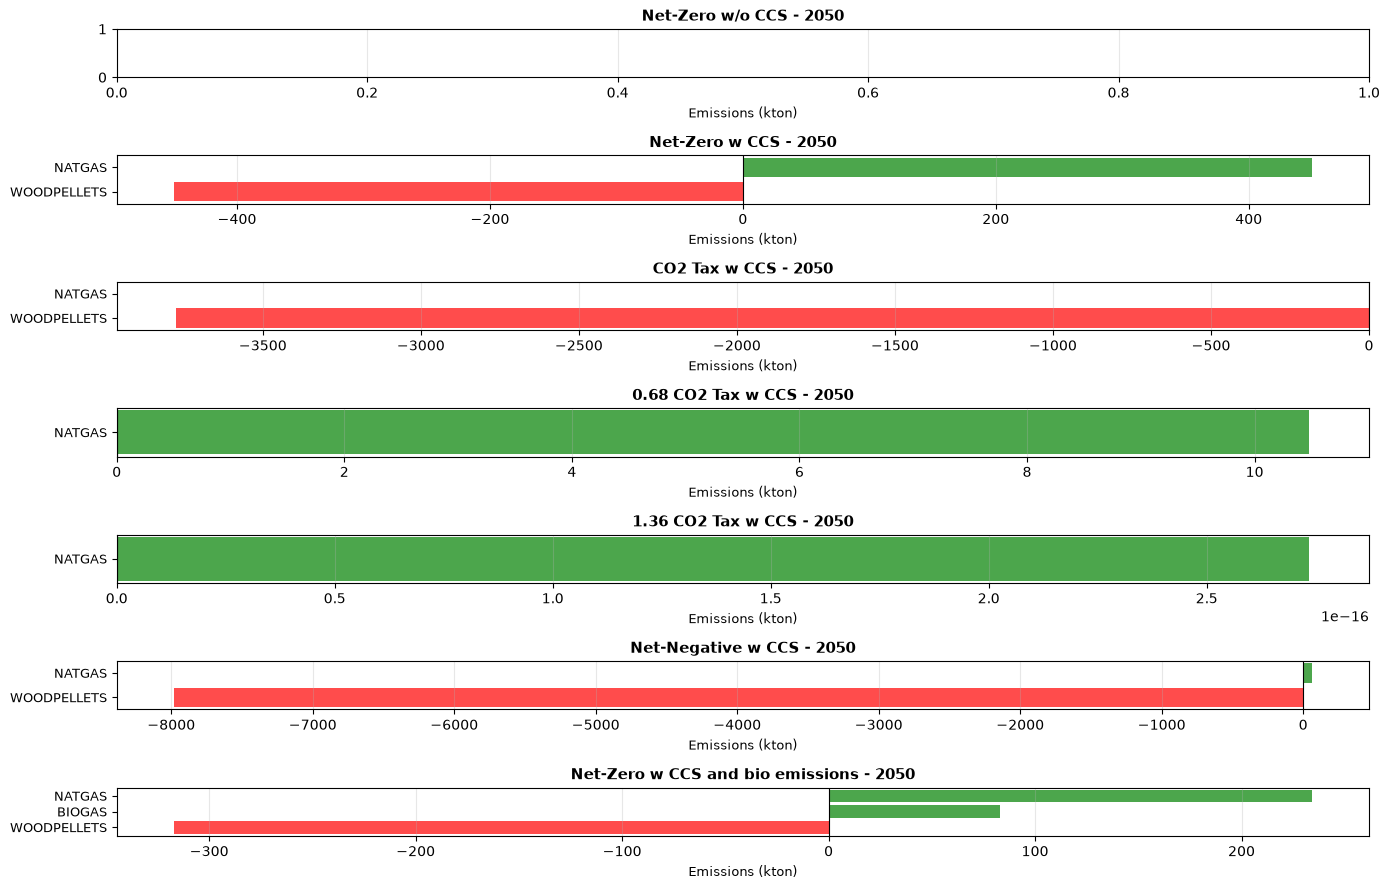

In [15]:
scenarios = [
    "Net-Zero w/o CCS",
    "Net-Zero w CCS",
    "CO2 Tax w CCS",
    "0.68 CO2 Tax w CCS",
    "1.36 CO2 Tax w CCS",
    "Net-Negative w CCS",
    "Net-Zero w CCS and bio emissions",
]
years = [2050]
fig, axes = pf.plot_emissions_grid_by_year_and_scenario(
    EMI_YCRAG, years=years, scenarios=scenarios
)

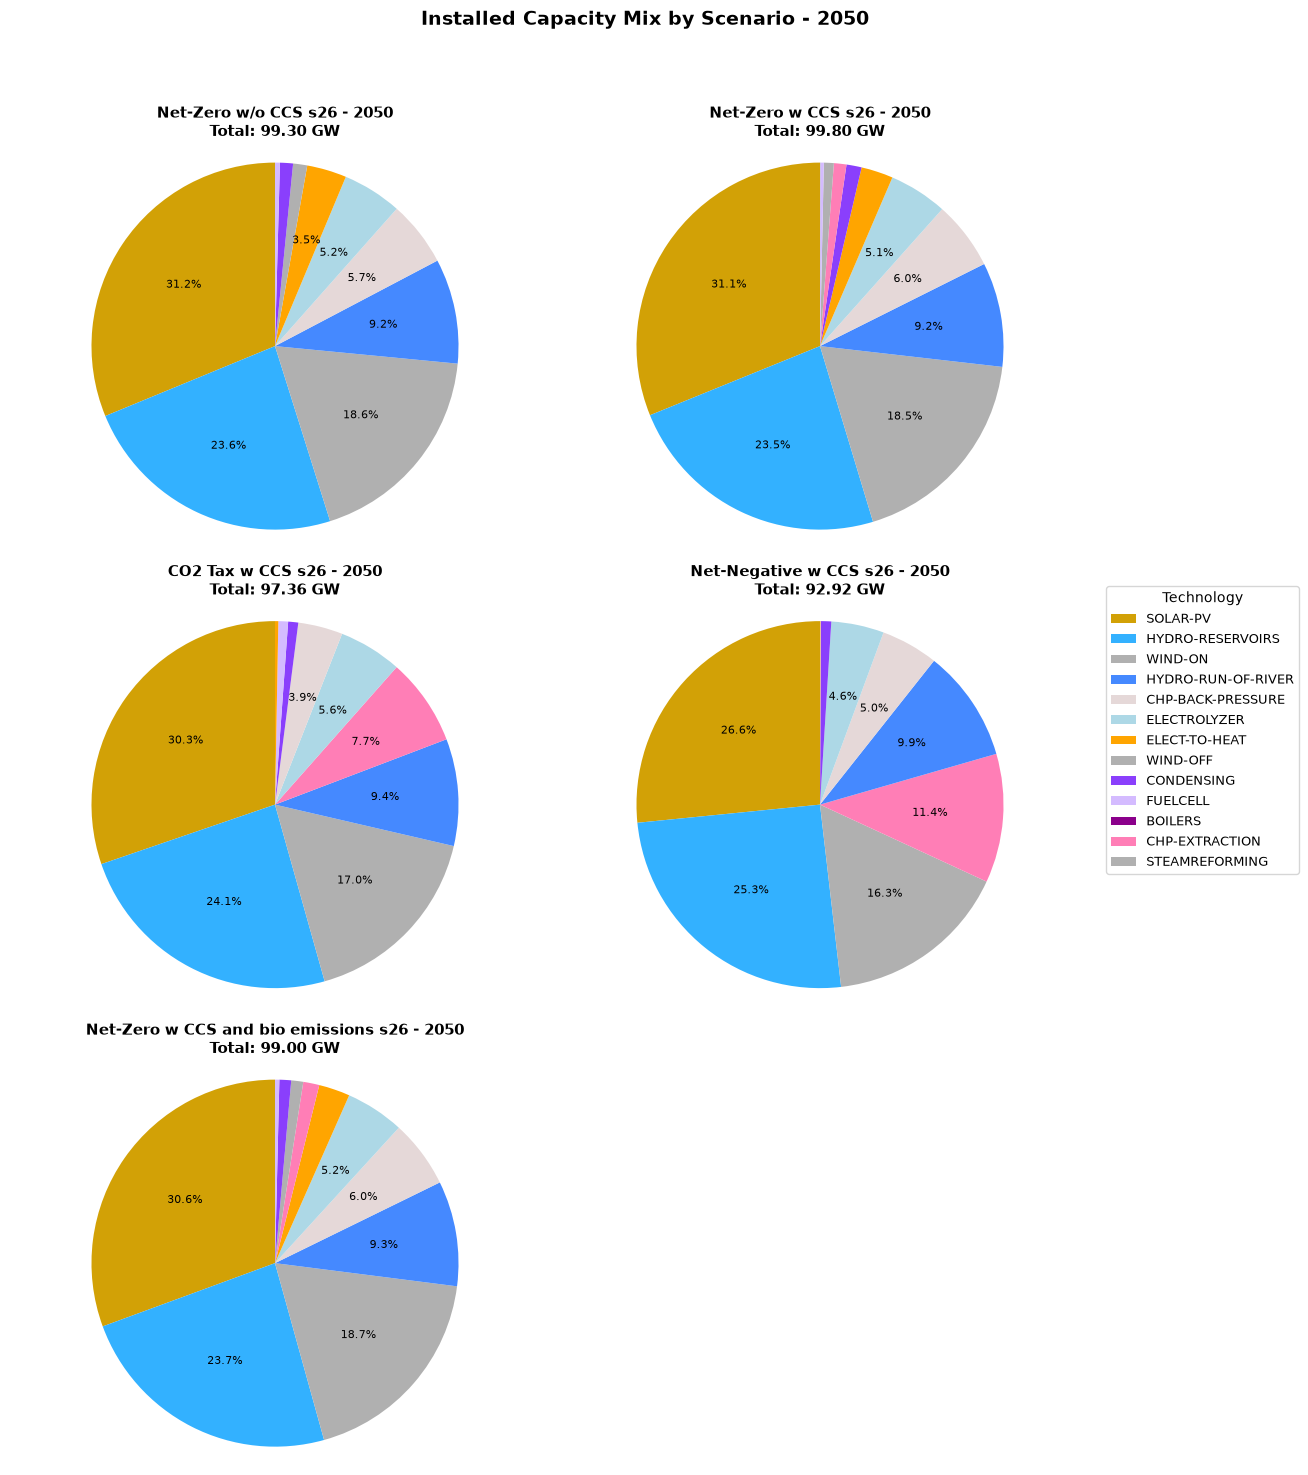

In [61]:
scenarios = [
    "Net-Zero w/o CCS s26",
    "Net-Zero w CCS s26",
    "CO2 Tax w CCS s26",
    "Net-Negative w CCS s26",
    "Net-Zero w CCS and bio emissions s26",
]

fig, ax = pf.plot_capacity_pie_by_scenario(
    G_CAP_YCRAF,
    year=2050,
    scenarios=scenarios,
    min_capacity=0.0,
)

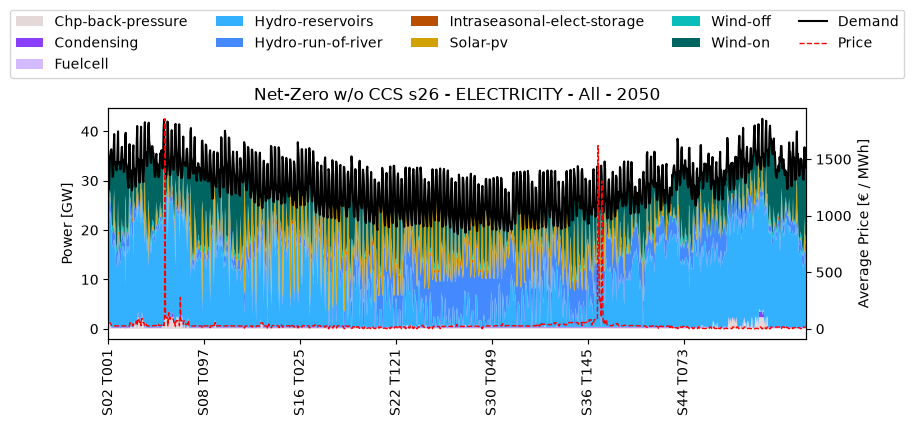

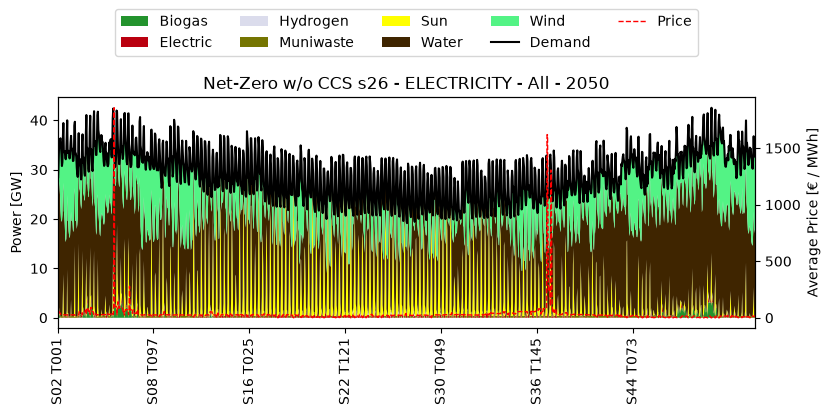

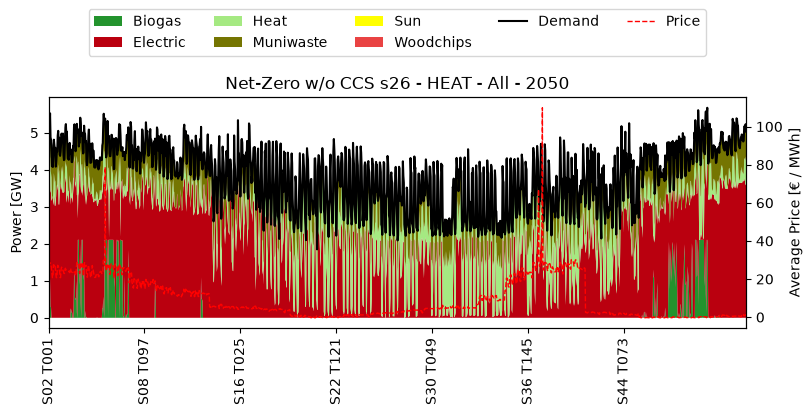

In [19]:
fig, ax = res.plot_profile(scenario='Net-Zero w/o CCS s26', year=2050, commodity='Electricity', columns='Technology')
fig, ax = res.plot_profile(scenario='Net-Zero w/o CCS s26', year=2050, commodity='Electricity', columns='Fuel')
fig, ax = res.plot_profile(scenario='Net-Zero w/o CCS s26', year=2050, commodity='Heat', columns='Fuel')

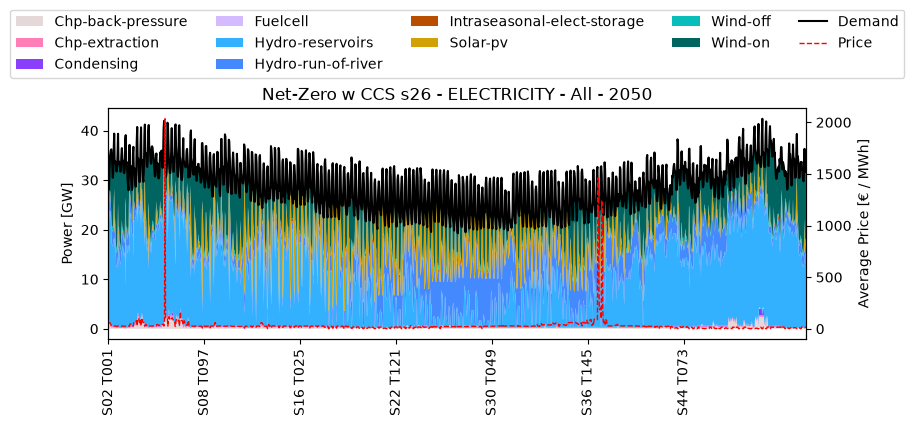

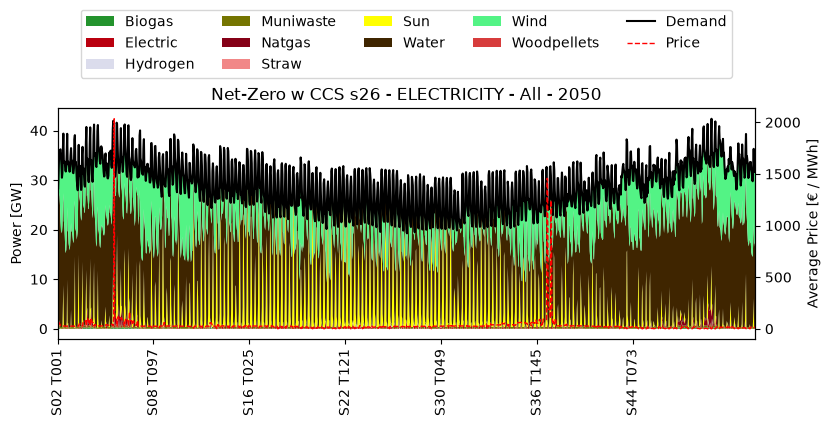

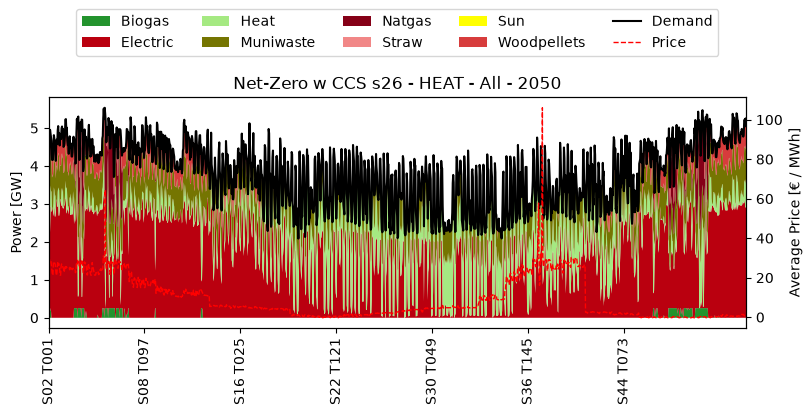

In [65]:
fig, ax = res.plot_profile(scenario='Net-Zero w CCS s26', year=2050, commodity='Electricity', columns='Technology')
fig, ax = res.plot_profile(scenario='Net-Zero w CCS s26', year=2050, commodity='Electricity', columns='Fuel')
fig, ax = res.plot_profile(scenario='Net-Zero w CCS s26', year=2050, commodity='Heat', columns='Fuel')

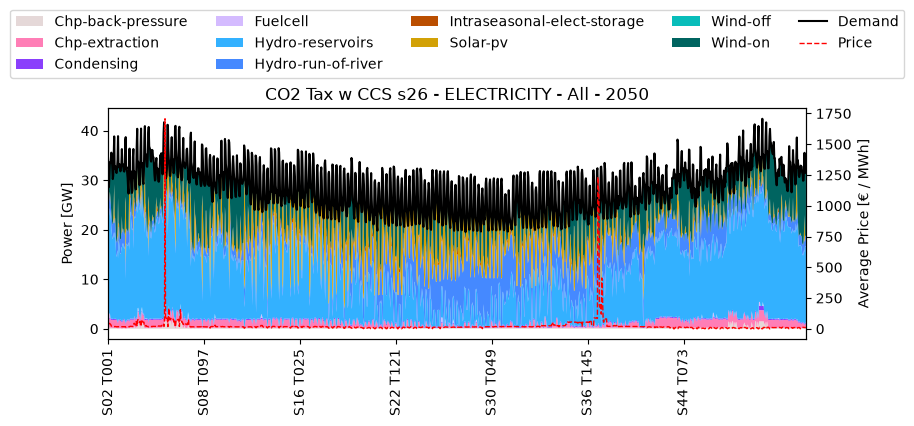

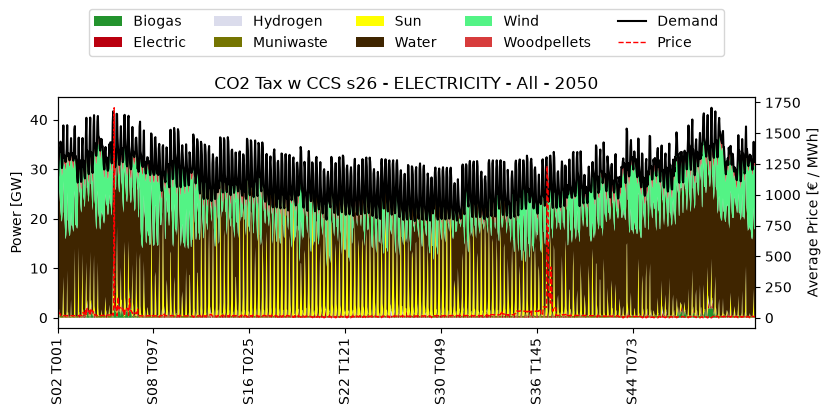

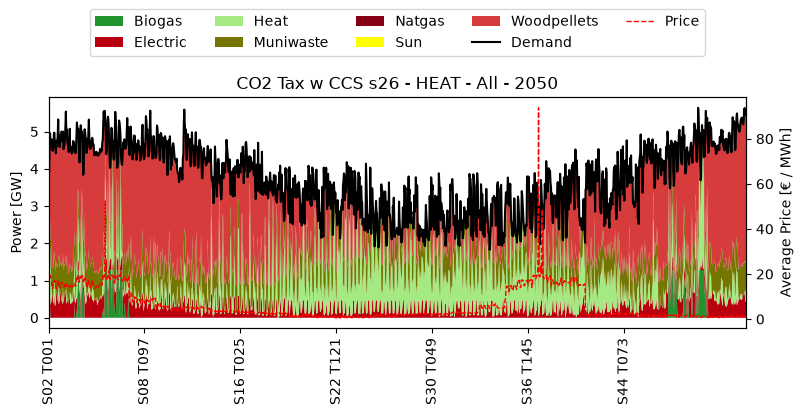

In [66]:
fig, ax = res.plot_profile(scenario='CO2 Tax w CCS s26', year=2050, commodity='Electricity', columns='Technology')
fig, ax = res.plot_profile(scenario='CO2 Tax w CCS s26', year=2050, commodity='Electricity', columns='Fuel')
fig, ax = res.plot_profile(scenario='CO2 Tax w CCS s26', year=2050, commodity='Heat', columns='Fuel')

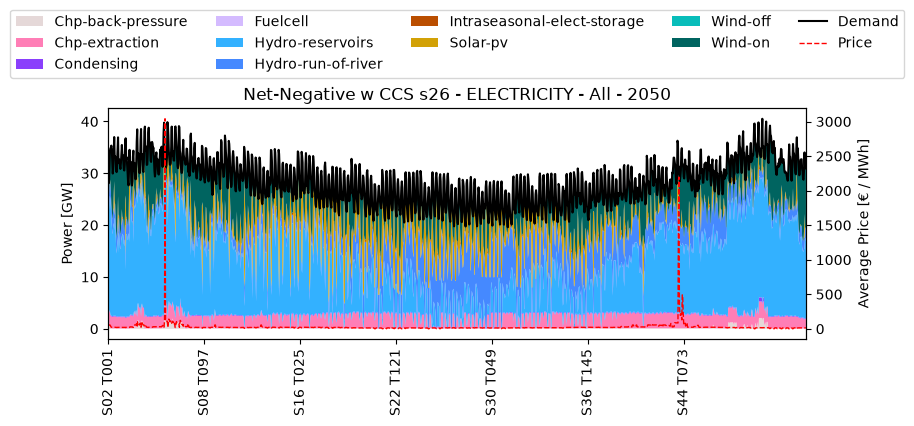

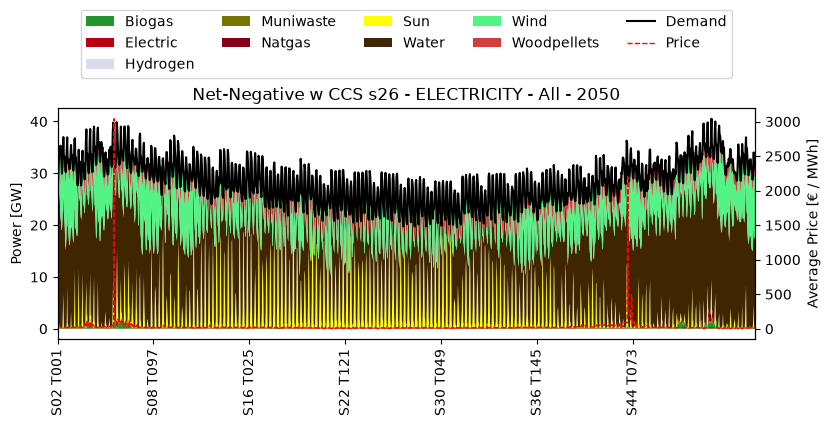

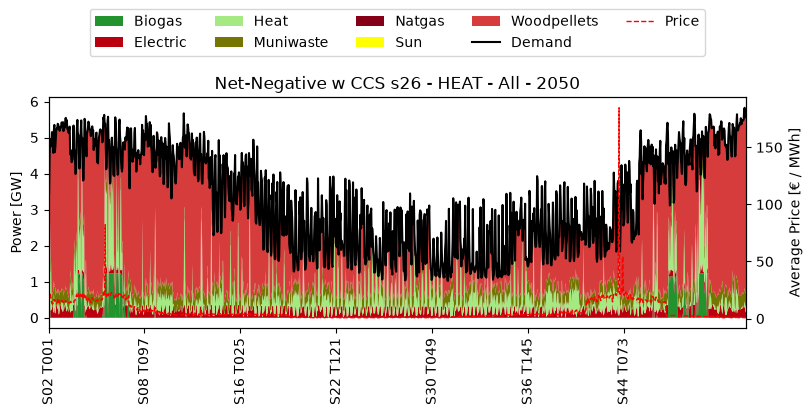

In [67]:
fig, ax = res.plot_profile(scenario='Net-Negative w CCS s26', year=2050, commodity='Electricity', columns='Technology')
fig, ax = res.plot_profile(scenario='Net-Negative w CCS s26', year=2050, commodity='Electricity', columns='Fuel')
fig, ax = res.plot_profile(scenario='Net-Negative w CCS s26', year=2050, commodity='Heat', columns='Fuel')

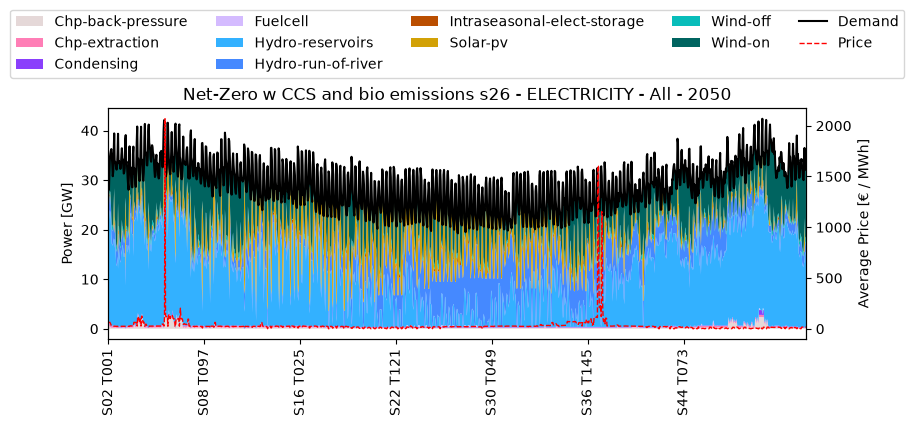

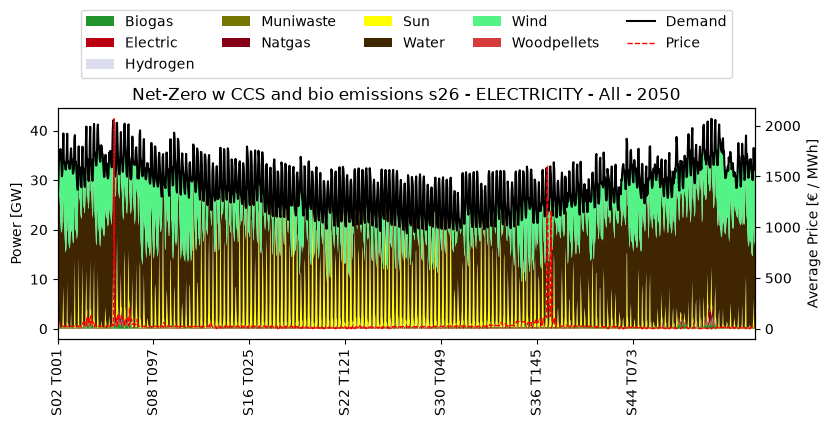

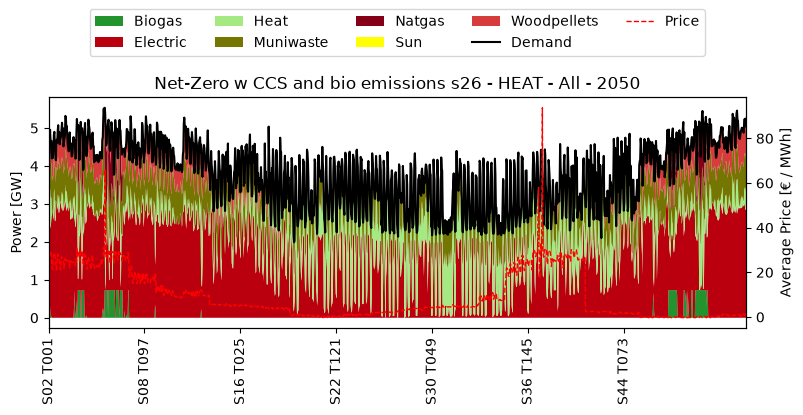

In [68]:
fig, ax = res.plot_profile(scenario='Net-Zero w CCS and bio emissions s26', year=2050, commodity='Electricity', columns='Technology')
fig, ax = res.plot_profile(scenario='Net-Zero w CCS and bio emissions s26', year=2050, commodity='Electricity', columns='Fuel')
fig, ax = res.plot_profile(scenario='Net-Zero w CCS and bio emissions s26', year=2050, commodity='Heat', columns='Fuel')

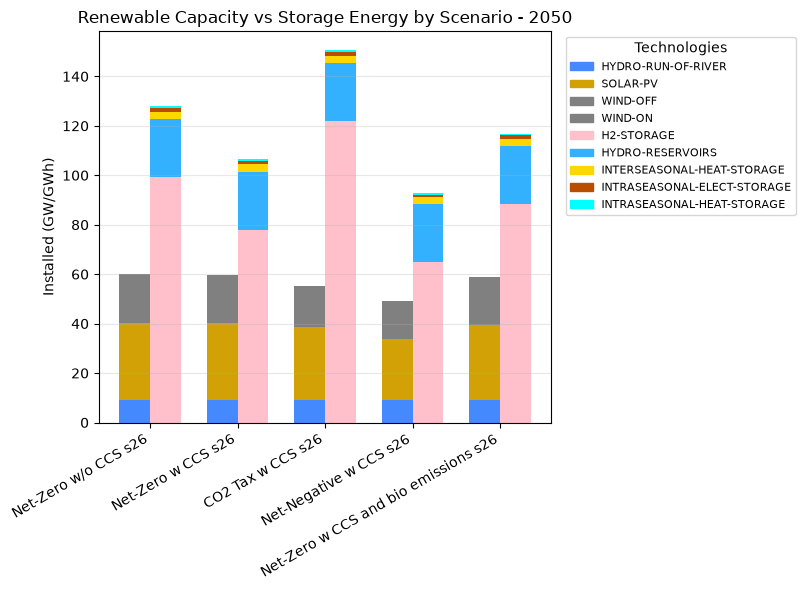

In [69]:
fig, ax = pf.plot_renewables_vs_storage_by_tech(G_CAP_YCRAF, year=2050, scenarios=["Net-Zero w/o CCS s26","Net-Zero w CCS s26","CO2 Tax w CCS s26","Net-Negative w CCS s26","Net-Zero w CCS and bio emissions s26"], min_capacity=0.0)

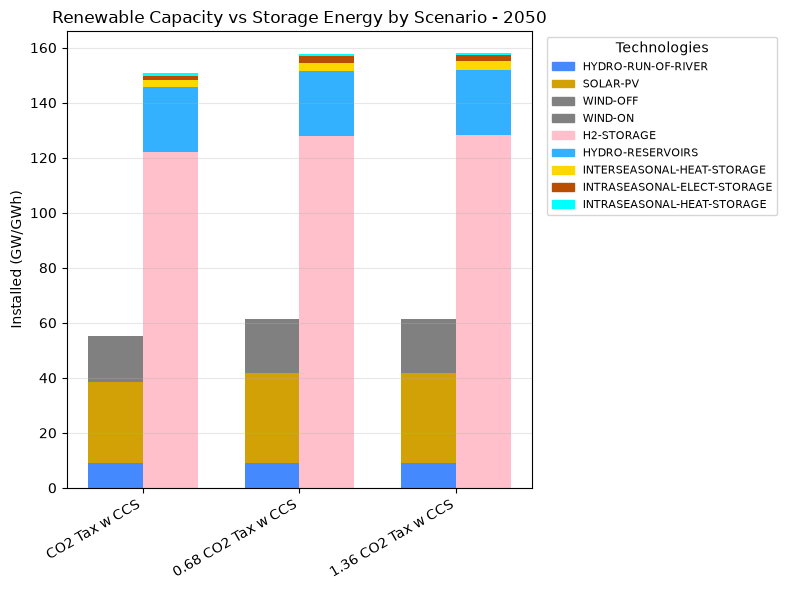

In [16]:
fig, ax = pf.plot_renewables_vs_storage_by_tech(G_CAP_YCRAF, year=2050, scenarios=["CO2 Tax w CCS", "0.68 CO2 Tax w CCS", "1.36 CO2 Tax w CCS"], min_capacity=0.0)

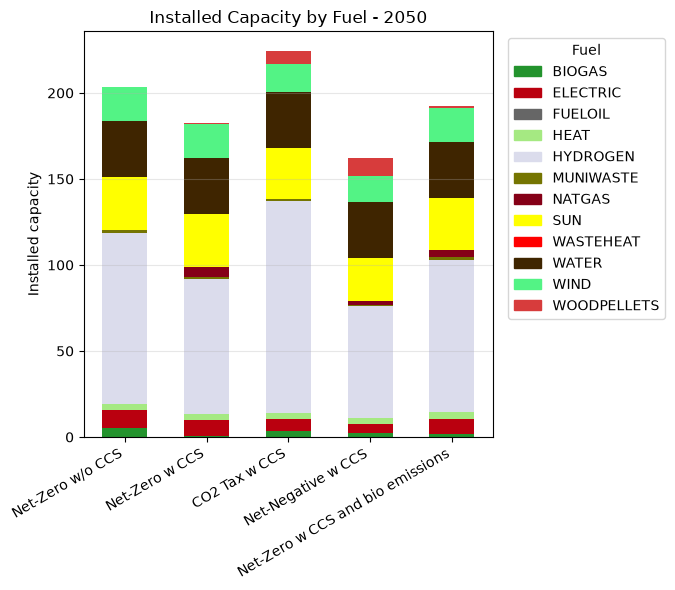

In [4]:
fig, ax = pf.plot_capacity_by_fuel(G_CAP_YCRAF, year=2050, scenarios=["Net-Zero w/o CCS", "Net-Zero w CCS", "CO2 Tax w CCS", "Net-Negative w CCS", "Net-Zero w CCS and bio emissions"])

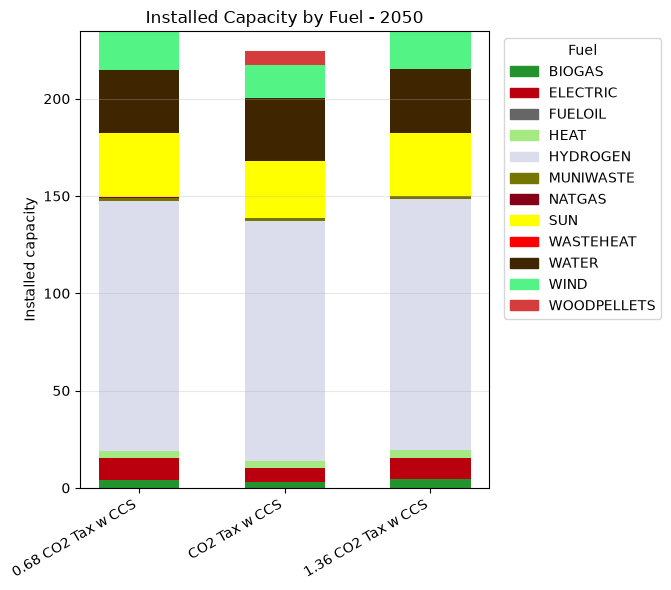

In [5]:
fig, ax = pf.plot_capacity_by_fuel(G_CAP_YCRAF, year=2050, scenarios=["0.68 CO2 Tax w CCS", "CO2 Tax w CCS", "1.36 CO2 Tax w CCS"])

          Scenario  CO2_price  Renewable_GW   CCS_GW
0.68 CO2 Tax w CCS      87.00     72.479606 0.000000
     CO2 Tax w CCS     127.77     66.429306 7.474294
1.36 CO2 Tax w CCS     174.00     72.470422 0.000000


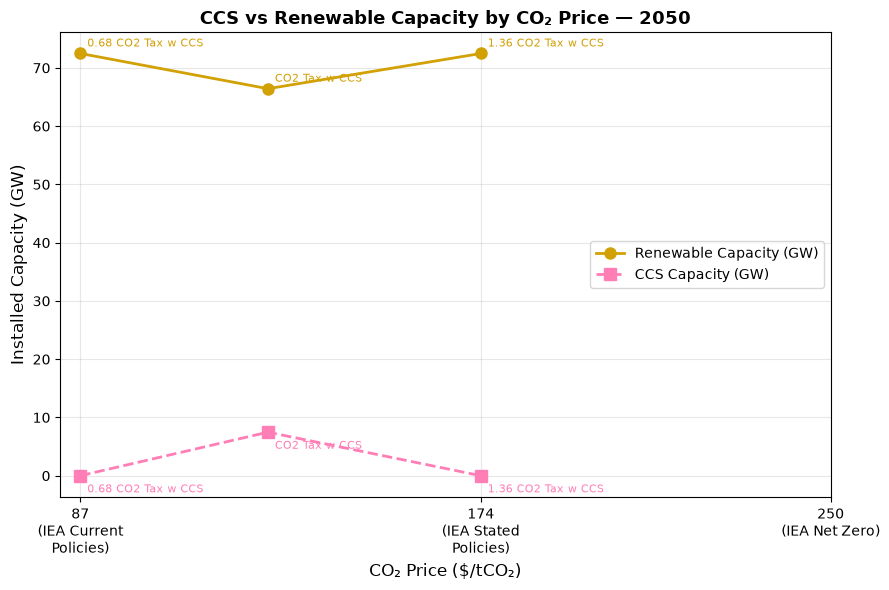

In [24]:
from pathlib import Path
co2_prices = {
    #'CO2 Tax w CCS 0.5': 65,
    '0.68 CO2 Tax w CCS': 87,
    'CO2 Tax w CCS': 127.77,
    '1.36 CO2 Tax w CCS': 174,
    #'CO2 Tax w CCS 1.95': 250,
}

def read_ccs_generators_from_inc(inc_path):
    text = Path(inc_path).read_text(encoding="utf-8", errors="ignore")
    generators = []
    for raw_line in text.splitlines():
        line = raw_line.strip()
        if not line or line.upper().startswith("SET "):
            continue
        if line in {"/", "/;"} or line.endswith("/;"):
            continue
        if line.startswith("$"):
            tokens = line.split()
            if tokens:
                generators.append(tokens[-1].strip())
            continue
        generators.append(line.split()[0])
    return {g.upper() for g in generators if g and g not in {"/", "/;"}}

ccs_inc_path = Path("Balmorel/04Project_CO2TaxwCCS/Data/CCS_CCS_G.inc")
ccs_generators = read_ccs_generators_from_inc(ccs_inc_path)

fig, ax = pf.plot_ccs_vs_renewables_by_co2price(
    capacity_df=G_CAP_YCRAF,
    co2_prices=co2_prices,
    year=2050,
    scenarios=list(co2_prices.keys()),
    ccs_generators=list(ccs_generators),
)

renewable_keywords = ["wind", "solar", "pv", "run",'bio','biomass','geothermal']
df = G_CAP_YCRAF.copy()
df["Scenario_clean"] = df["Scenario"].astype(str).str.strip()
df["Year"] = df["Year"].astype(int)
df["Generation_upper"] = df["Generation"].astype(str).str.strip().str.upper()
df = df[(df["Year"] == 2050) & (df["Scenario_clean"].isin(co2_prices.keys())) & (df["Value"] > 0)]

results = []
for scenario, co2_price in co2_prices.items():
    d = df[df["Scenario_clean"] == scenario]
    renewable_cap = d[d["Technology"].astype(str).str.lower().str.contains("|".join(renewable_keywords), na=False)]["Value"].sum()
    ccs_cap = d[d["Generation_upper"].isin(ccs_generators)]["Value"].sum()
    results.append({
        "Scenario": scenario,
        "CO2_price": co2_price,
        "Renewable_GW": renewable_cap,
        "CCS_GW": ccs_cap,
    })

results_df = pd.DataFrame(results).sort_values("CO2_price")
print(results_df.to_string(index=False))

In [25]:
ccs_generators

{'BIOMASS_CHP_W_CCS',
 'GNR_BO_NGASCCS_E-105_MS-5-MW_Y-2020',
 'GNR_BO_NGASCCS_E-106_MS-5-MW_Y-2030',
 'GNR_BO_NGASCCS_E-106_MS-5-MW_Y-2040',
 'GNR_BO_NGASCCS_E-106_MS-5-MW_Y-2050',
 'GNR_BO_WOODCHI_E-115_LS-7-MW_Y-2050_CCS',
 'GNR_CC_NGASCCS_BP_E-51_SS-10-MW_Y-2020',
 'GNR_CC_NGASCCS_BP_E-53_SS-10-MW_Y-2030',
 'GNR_CC_NGASCCS_BP_E-54_SS-10-MW_Y-2040',
 'GNR_CC_NGASCCS_BP_E-55_SS-10-MW_Y-2050',
 'GNR_CC_NGASCCS_CND_E-51_SS-10-MW_Y-2020',
 'GNR_CC_NGASCCS_CND_E-53_SS-10-MW_Y-2030',
 'GNR_CC_NGASCCS_CND_E-54_SS-10-MW_Y-2040',
 'GNR_CC_NGASCCS_CND_E-55_SS-10-MW_Y-2050',
 'GNR_CC_NGASCCS_CND_E-59_LS-100-MW_Y-2020',
 'GNR_CC_NGASCCS_CND_E-61_LS-100-MW_Y-2030',
 'GNR_CC_NGASCCS_CND_E-62_LS-100-MW_Y-2040',
 'GNR_CC_NGASCCS_CND_E-63_LS-100-MW_Y-2050',
 'GNR_CC_NGASCCS_EXT_E-59_LS-100-MW_Y-2020',
 'GNR_CC_NGASCCS_EXT_E-61_LS-100-MW_Y-2030',
 'GNR_CC_NGASCCS_EXT_E-62_LS-100-MW_Y-2040',
 'GNR_CC_NGASCCS_EXT_E-63_LS-100-MW_Y-2050',
 'GNR_ENG_NGASCCS_BP_E-47_Y-2020',
 'GNR_ENG_NGASCCS_BP_E-48_Y-203